In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML

import fargopy as fp
from fargopy import DEG, RAD
%load_ext autoreload
%autoreload 2

Your configuration file version '1.0.7' it is different than the installed version of FARGOpy '1.1.1'
Running FARGOpy version 1.1.1. A major refactor has been done in versions 1.1.X. Please check the documentation for more information.


In [ ]:
simpath = fp.Simulation.download_precomputed(setup='fargo')

Precomputed output directory '/tmp/fargo' already exist


In [ ]:
sim = fp.Simulation(output_dir=simpath)

Your simulation is now connected with '/home/fargopy/fargo3d/'
Now you are connected with output directory '/tmp/fargo'
Found a variables.par file in '/tmp/fargo', loading properties
Loading variables
84 variables loaded
Simulation in 2 dimensions
Loading domain in cylindrical coordinates:
	Variable phi: 384 [[0, np.float64(-3.1334114227210694)], [-1, np.float64(3.1334114227210694)]]
	Variable r: 128 [[0, np.float64(0.408203125)], [-1, np.float64(2.491796875)]]
	Variable z: 1 [[0, np.float64(0.0)], [-1, np.float64(0.0)]]
Number of snapshots in output directory: 51
Planets found in summary.dat
  Name: Jupiter, Initial pos: [1.0, 0.001, 0.0], Mass: 0.001


In [ ]:

sim.load_properties()

Loading variables
84 variables loaded
Simulation in 2 dimensions
Loading domain in cylindrical coordinates:
	Variable phi: 384 [[0, np.float64(-3.1334114227210694)], [-1, np.float64(3.1334114227210694)]]
	Variable r: 128 [[0, np.float64(0.408203125)], [-1, np.float64(2.491796875)]]
	Variable z: 1 [[0, np.float64(0.0)], [-1, np.float64(0.0)]]
Number of snapshots in output directory: 51
Planets found in summary.dat
  Name: Jupiter, Initial pos: [1.0, 0.001, 0.0], Mass: 0.001


In [ ]:
dens = sim.load_field('gasdens', slice='z=0, r=[0.8,1.2],phi=[-10 deg, 10 deg]', snapshot=10,coords='cartesian')

In [ ]:
x = dens.var1_mesh[0]
y = dens.var2_mesh[0]
rho = dens.gasdens_mesh[0]

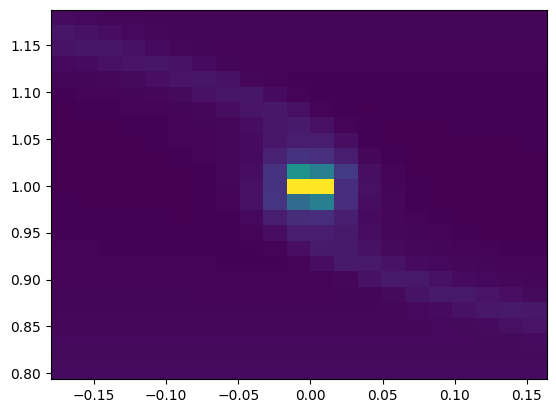

In [6]:
plt.pcolormesh(dens.var1_mesh[0], dens.var2_mesh[0], dens.gasdens_mesh[0])

In [7]:
import fargopy as fp

# Cargar simulación (detecta automáticamente si es cilíndrica o esférica)

sim.load_properties()

# Cargar campo con slice en z=0 (plano XY para cilíndricas)
dens = sim.load_field('gasdens', slice='z=0', snapshot=10)

# Cargar campo con slice en phi=0 (plano RZ para cilíndricas)
dens_rz = sim.load_field('gasdens', slice='phi=0', snapshot=10)

# Exportar a ParaView (detecta automáticamente el sistema)
sim.export_vtu(snapshot=10, dir='output')

# Calcular masa encerrada (funciona con ambos sistemas)
surface = fp.Flux.Surface(type='sphere', radius=1.0)
mass = surface.total_mass(sim, field='gasdens', snapshot=10)

Loading variables
84 variables loaded
Simulation in 2 dimensions
Loading domain in cylindrical coordinates:
	Variable phi: 384 [[0, np.float64(-3.1334114227210694)], [-1, np.float64(3.1334114227210694)]]
	Variable r: 128 [[0, np.float64(0.408203125)], [-1, np.float64(2.491796875)]]
	Variable z: 1 [[0, np.float64(0.0)], [-1, np.float64(0.0)]]
Number of snapshots in output directory: 51
Planets found in summary.dat
  Name: Jupiter, Initial pos: [1.0, 0.001, 0.0], Mass: 0.001


AttributeError: 'Simulation' object has no attribute 'export_vtu'

In [7]:
surface = fp.Surface(type='sphere', radius=1.0)


In [8]:
mass = surface.total_mass(sim, field='gasdens', snapshot=10)

ValueError: total_mass() requires a 3D simulation. Your simulation is 2D. Volume integration cannot be performed in 2D domains.